# Use Case: Heatwave Evolution (Historical vs SSP585)

This notebook demonstrates how to use `earthkit-climate` to analyze how summer heatwaves evolve under climate change. We compare a recent historical decade (2005-2014) with a future decade under the SSP585 scenario (2091-2100).

We use:

- **`heat_wave_frequency`**: Number of heatwaves per year.
- **`heat_wave_total_length`**: Total number of days in a heatwave per year.

A heatwave is defined as at least 3 consecutive days during summer (JJA) where both daily Tmin > 22°C and Tmax > 30°C.

In [1]:
import warnings

import earthkit.data as ekd
import earthkit.plots as ekp
import numpy
import xarray

from earthkit.climate.atmos import temperature

warnings.filterwarnings("ignore")

## Loading Data

We load both historical and SSP585 daily temperature data.

In [2]:
def load_scenario(scenario):
    filename_map = {"historical": "ACCESS-CM2_historical_reference", "ssp585": "ACCESS-CM2_ssp585_far_future"}
    return (
        ekd.from_source("earthkit-climate-sample", f"tasmin_{filename_map[scenario]}").to_xarray(),
        ekd.from_source("earthkit-climate-sample", f"tasmax_{filename_map[scenario]}").to_xarray(),
    )


ds_tasmin_hist, ds_tasmax_hist = load_scenario("historical")
ds_tasmin_ssp, ds_tasmax_ssp = load_scenario("ssp585")

## Computing Heatwave Indices

We define a heatwave as a period of at least 3 consecutive days during summer (JJA) where:
- The daily **minimum** temperature exceeds **22°C** (`thresh_tasmin`)
- The daily **maximum** temperature exceeds **30°C** (`thresh_tasmax`)

Both conditions must be satisfied simultaneously.

*Note: These thresholds are adapted to the sample dataset to ensure non-zero results for demonstration. In a real-world study, these should be chosen based on the local climatology.*


In [3]:
thresh_tasmin = "22.0 degC"
thresh_tasmax = "30.0 degC"
window = 3


def compute_indices(ds_tasmin: xarray.Dataset, ds_tasmax: xarray.Dataset):
    """Compute heatwave frequency and total length."""
    hw_args = dict(
        thresh_tasmin=thresh_tasmin,
        thresh_tasmax=thresh_tasmax,
        window=window,
        freq="YS",
    )
    hwf = temperature.heat_wave_frequency(ds_tasmin.tasmin, ds_tasmax.tasmax, **hw_args)
    hwt = temperature.heat_wave_total_length(ds_tasmin.tasmin, ds_tasmax.tasmax, **hw_args)
    for da in [hwf, hwt]:
        if da.attrs.get("units") == "1":
            da.attrs["units"] = "dimensionless"
    return hwf, hwt


hwf_hist, hwt_hist = compute_indices(ds_tasmin_hist, ds_tasmax_hist)
hwf_ssp, hwt_ssp = compute_indices(ds_tasmin_ssp, ds_tasmax_ssp)

## Decadal Aggregation and Comparison

We calculate the average for the last decade of the historical period (2005-2014) and the future period (2091-2100).

In [4]:
hwf_hist_mean = hwf_hist.mean(dim="time", keep_attrs=True)
hwt_hist_mean = hwt_hist.mean(dim="time", keep_attrs=True)

hwf_ssp_mean = hwf_ssp.mean(dim="time", keep_attrs=True)
hwt_ssp_mean = hwt_ssp.mean(dim="time", keep_attrs=True)

hwf_anomaly = hwf_ssp_mean - hwf_hist_mean
hwf_anomaly.attrs.update(hwf_hist.attrs)
hwt_anomaly = hwt_ssp_mean - hwt_hist_mean
hwt_anomaly.attrs.update(hwt_hist.attrs)

## Visualization

Let's visualize the anomalies in heatwave frequency and length.

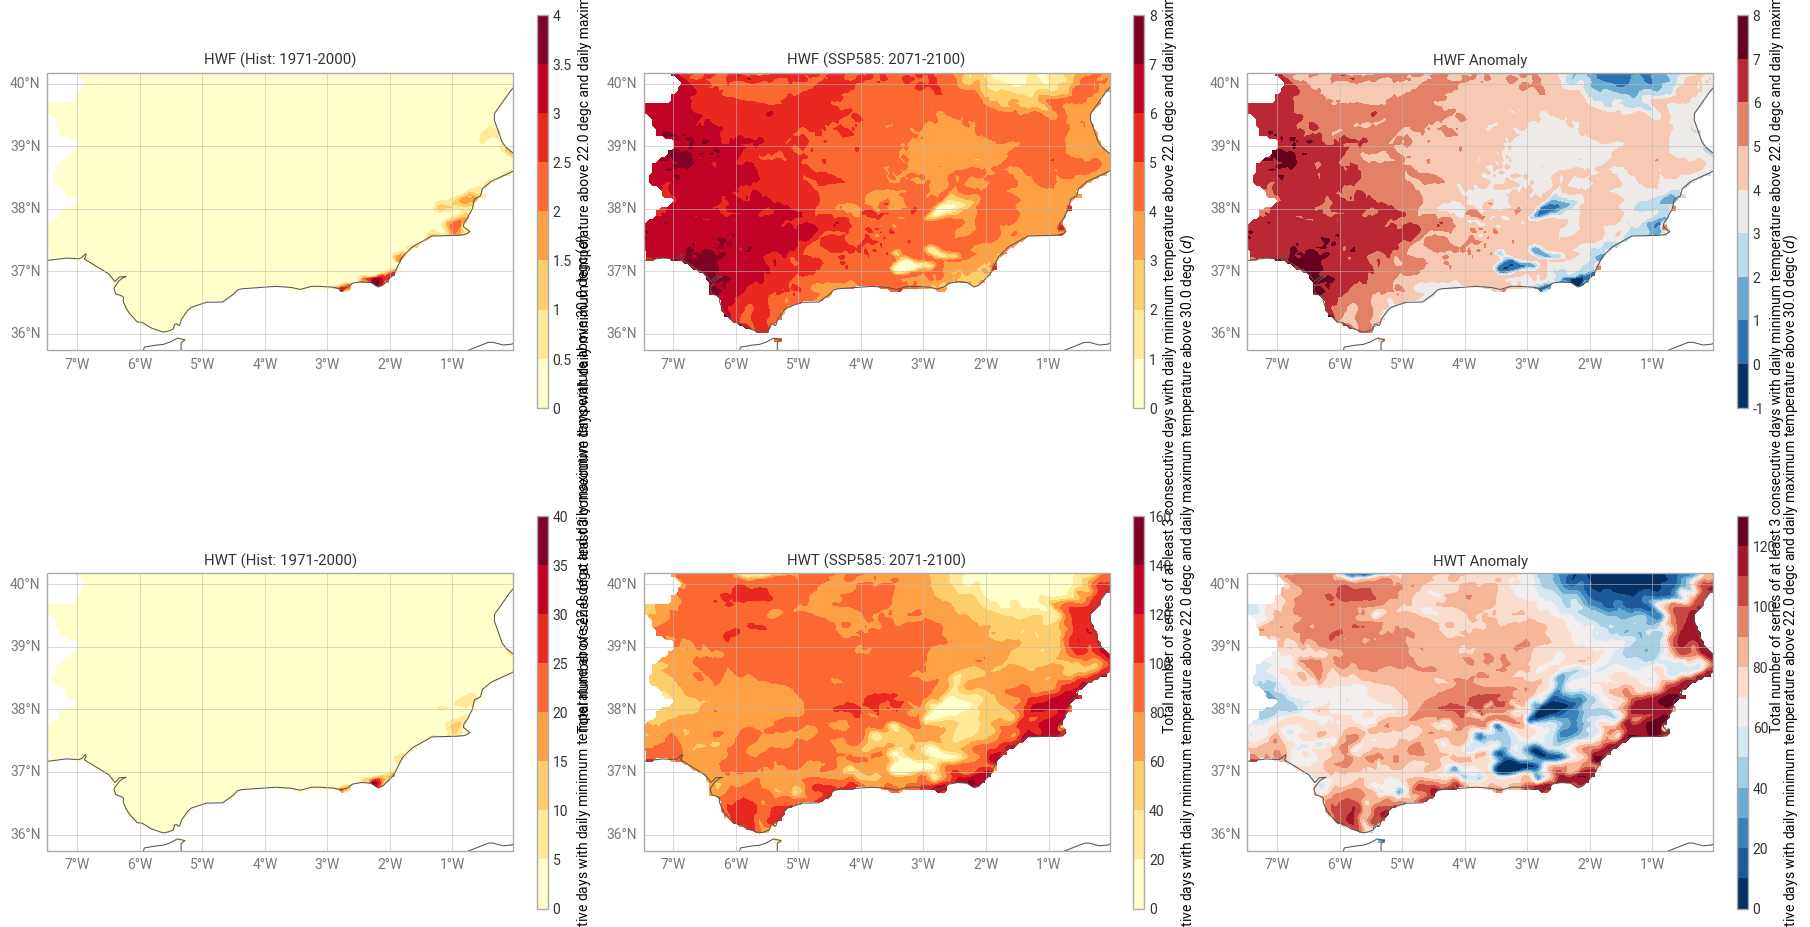

In [5]:
figure = ekp.Figure(rows=2, columns=3, size=(18, 10))
plot_matrix = [
    [
        ("HWF (Hist: 1971-2000)", hwf_hist_mean, "YlOrRd"),
        ("HWF (SSP585: 2071-2100)", hwf_ssp_mean, "YlOrRd"),
        ("HWF Anomaly", hwf_anomaly, "RdBu_r"),
    ],
    [
        ("HWT (Hist: 1971-2000)", hwt_hist_mean, "YlOrRd"),
        ("HWT (SSP585: 2071-2100)", hwt_ssp_mean, "YlOrRd"),
        ("HWT Anomaly", hwt_anomaly, "RdBu_r"),
    ],
]
for row_idx, row_plots in enumerate(plot_matrix):
    for col_idx, (name, data, cmap) in enumerate(row_plots):
        map_plot = figure.add_map(row=row_idx, column=col_idx)
        valid_data = data.values[~numpy.isnan(data.values)]
        if valid_data.size == 0:
            map_plot.title(f"{name} (No data)")
        elif numpy.all(valid_data == valid_data[0]):
            style = ekp.styles.Style(colors=cmap, levels=[valid_data[0] - 1, valid_data[0] + 1])
            map_plot.quickplot(data, style=style)
        else:
            style = ekp.styles.Style(colors=cmap)
            map_plot.quickplot(data, style=style)
        map_plot.coastlines()
        map_plot.gridlines()
        map_plot.title(name)
        map_plot.legend(location="right")
figure.show()

### Analysis of Heat Wave Evolution: Historical vs. Future Projections (SSP5-8.5)

This section evaluates the intensification of heat waves over the southern Iberian Peninsula by comparing the **Historical baseline (1971-2000)** with the **long-term future (2071-2100)** under the high-emission **SSP5-8.5** scenario.

#### Key Observations
* **Heat Wave Frequency (HWF):** The top row illustrates a drastic shift. While the historical period (left) shows heat waves as rare events restricted to small coastal pockets, the future projection (center) indicates a widespread increase. The **HWF Anomaly** (right) confirms that the frequency will rise by up to **8 events per period**, with the highest impact in the **Guadalquivir Valley and southwestern regions**.
* **Heat Wave Total Days (HWT):** The bottom row reveals an even more critical trend in duration. From a baseline of near-zero days, the end-of-century scenario projects over **120 to 140 cumulative days** of heat wave conditions. 
* **Spatial Patterns:** The **HWT Anomaly** highlights a "hotspot" along the **Mediterranean coast and the southern interior**. This suggests that while inland areas see more frequent events, coastal and southern regions will face significantly longer-lasting heat stress, likely due to the compounding effect of high nighttime temperatures.

#### Climate Implication
The transition from the historical "yellow" maps to the future "deep red" maps signifies a regime shift: what were once extreme, outlier events are projected to become a dominant feature of the summer climate by 2100.